# Step 1 - Data Exploration 

This notebook contains all of the code used to perform data exploration. No changes are done in thsi notebook. These steps are simply to get a better understanding of the data. 

In [1]:
# Import the paackages used in this notebook
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
# Read in the data from Coursera 
bitcoin_df = pd.read_csv("data/bitcoin.csv")

In [3]:
# Get a summary of the dataset
bitcoin_df.describe()

,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,btc_hash_rate,...,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
count,2920.000000,2.920000e+03,2.920000e+03,2.899000e+03,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2.920000e+03,...,2920.000000,2920.000000,2.920000e+03,2920.000000,2.920000e+03,2920.000000,2920.000000,2.920000e+03,2.920000e+03,2.920000e+03
mean,897.485562,1.152051e+07,1.443022e+10,8.231157e+07,36058.374765,0.355733,0.362329,677.010924,7.547221,1.387725e+06,...,58.079229,15.237677,1.959608e+05,102922.695548,7.016399e+07,95187.560616,63770.210274,1.568570e+06,2.038262e+05,2.118495e+08
std,2400.159935,4.200938e+06,4.029263e+10,3.116642e+08,44536.901058,0.356388,0.840614,689.042018,4.956135,3.379005e+06,...,1709.115660,21.638354,2.093837e+05,103846.693961,8.475145e+07,103941.129363,69733.896388,2.272542e+06,2.675688e+05,5.903811e+08
min,0.000000,2.110700e+06,0.000000e+00,0.000000e+00,0.000000,0.000216,0.000000,1.000000,0.000000,2.657847e-05,...,0.136531,0.000000,1.100000e+02,118.000000,4.261300e+04,118.000000,118.000000,6.150000e+03,7.000000e+00,0.000000e+00
25%,6.768750,8.405100e+06,5.560588e+07,2.994316e+05,777.250000,0.024595,0.000000,55.000000,6.129167,1.169741e+01,...,1.180738,4.220581,1.719000e+04,8157.000000,2.484693e+06,6995.500000,6888.750000,4.975323e+05,9.660900e+04,9.889582e+05
50%,236.310000,1.242910e+07,3.364730e+09,1.024364e+07,15132.000000,0.199806,0.000000,378.500000,7.933333,2.640642e+04,...,2.461625,7.865943,1.325365e+05,63006.000000,3.340692e+07,55015.500000,35670.000000,1.118162e+06,1.787410e+05,3.899174e+07
75%,603.909050,1.523764e+07,8.210042e+09,2.934823e+07,59301.750000,0.688036,0.000000,1238.569055,10.237500,1.097174e+06,...,5.844059,15.285634,3.666370e+05,191465.250000,1.116330e+08,187182.750000,114920.000000,2.028524e+06,2.587235e+05,1.369944e+08
max,19498.683333,1.687682e+07,3.265254e+11,5.352016e+09,157664.996336,1.110327,7.000000,2722.625000,47.733333,2.557925e+07,...,88571.428571,161.686071,1.072861e+06,490644.000000,3.005766e+08,470650.000000,318896.000000,4.599222e+07,5.825066e+06,5.760245e+09


In [4]:
# See the data types of each column 
bitcoin_df.dtypes

Date                                                    object
btc_market_price                                       float64
btc_total_bitcoins                                     float64
btc_market_cap                                         float64
btc_trade_volume                                       float64
btc_blocks_size                                        float64
btc_avg_block_size                                     float64
btc_n_orphaned_blocks                                  float64
btc_n_transactions_per_block                           float64
btc_median_confirmation_time                           float64
btc_hash_rate                                          float64
btc_difficulty                                         float64
btc_miners_revenue                                     float64
btc_transaction_fees                                   float64
btc_cost_per_transaction_percent                       float64
btc_cost_per_transaction                               

Note: All columns except "Date" are float values. Date needs to be converted to a date data type. 

In [8]:
# Identify columns that have missing values
bitcoin_df.isnull().sum()

Date                                                    0
btc_market_price                                        0
btc_total_bitcoins                                      0
btc_market_cap                                          0
btc_trade_volume                                       21
btc_blocks_size                                         0
btc_avg_block_size                                      0
btc_n_orphaned_blocks                                   0
btc_n_transactions_per_block                            0
btc_median_confirmation_time                            0
btc_hash_rate                                           0
btc_difficulty                                          0
btc_miners_revenue                                      0
btc_transaction_fees                                    0
btc_cost_per_transaction_percent                        0
btc_cost_per_transaction                                0
btc_n_unique_addresses                                  0
btc_n_transact

In [12]:
# Identify numerical columns that have values < 0.0 and = 0.0
num_cols = bitcoin_df.select_dtypes(include="number")
print("Columns with negative values: ", num_cols.columns[(num_cols < 0.0).any()])
print("Columns with 0.0 values: ", num_cols.columns[(num_cols == 0.0).any()])

Columns with negative values:  Index([], dtype='object')
Columns with 0.0 values:  Index(['btc_market_price', 'btc_market_cap', 'btc_trade_volume',
       'btc_blocks_size', 'btc_n_orphaned_blocks',
       'btc_median_confirmation_time', 'btc_miners_revenue',
       'btc_transaction_fees', 'btc_cost_per_transaction',
       'btc_estimated_transaction_volume_usd'],
      dtype='object')


There are no negative values but there are columns that have 0.0 values. 
- The only column that would make sense to have 0 values is `btc_n_orphaned_blocks` because there can be days with no orphaned blocks. These rows should be filtered out of the data. 
- For the remaining variables, 0 values seem like bad data unless we have data from early years when the Bitcoin wasn't in existance. 

In [13]:
# Take a look at the Data field
bitcoin_df.Date.head()

0    2010-02-23 00:00:00
1    2010-02-24 00:00:00
2    2010-02-25 00:00:00
3    2010-02-26 00:00:00
4    2010-02-27 00:00:00
Name: Date, dtype: object

In [14]:
bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Date'])

# Find the earliest and latest dates
date_min = bitcoin_df['Date'].min()
date_max = bitcoin_df['Date'].max()

print(f"Date range: {date_min} to {date_max}")

Date range: 2010-02-23 00:00:00 to 2018-02-20 00:00:00


In [16]:
# Let's see for what dates some of the variables have 0 values
for col in num_cols.columns:
    zero_dates = bitcoin_df.loc[bitcoin_df[col] == 0, 'Date']
    if not zero_dates.empty:
        start_date = zero_dates.min()
        end_date = zero_dates.max()
        print(f"Column '{col}' has 0 values from {start_date} to {end_date}")

Column 'btc_market_price' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_market_cap' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_trade_volume' has 0 values from 2010-02-23 00:00:00 to 2010-07-16 00:00:00
Column 'btc_blocks_size' has 0 values from 2010-02-23 00:00:00 to 2010-07-13 00:00:00
Column 'btc_n_orphaned_blocks' has 0 values from 2010-02-23 00:00:00 to 2018-02-20 00:00:00
Column 'btc_median_confirmation_time' has 0 values from 2010-02-23 00:00:00 to 2011-12-01 00:00:00
Column 'btc_miners_revenue' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_transaction_fees' has 0 values from 2010-02-23 00:00:00 to 2010-11-25 00:00:00
Column 'btc_cost_per_transaction' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_estimated_transaction_volume_usd' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00


All of the variables (except `btc_n_orphaned_blocks` and `btc_median_confirmation_time`) only have 0 values in the year 2010.

We already determined `btc_n_orphaned_blocks` = 0 to be valid. `btc_median_confirmation_time` can only be 0 if there were no transactions that day, but we've already confirmed that `btc_n_transactions_per_block` doesn't have any 0s.

Thus, my assumption is that 0s for the following variables can be filtered out due to bad/missing data: 
- 'btc_market_price'
- 'btc_market_cap'
- 'btc_trade_volume'
- 'btc_blocks_size'
- 'btc_median_confirmation_time'
- 'btc_miners_revenue'
- 'btc_transaction_fees'
- 'btc_cost_per_transaction'
- 'btc_estimated_transaction_volume_usd'

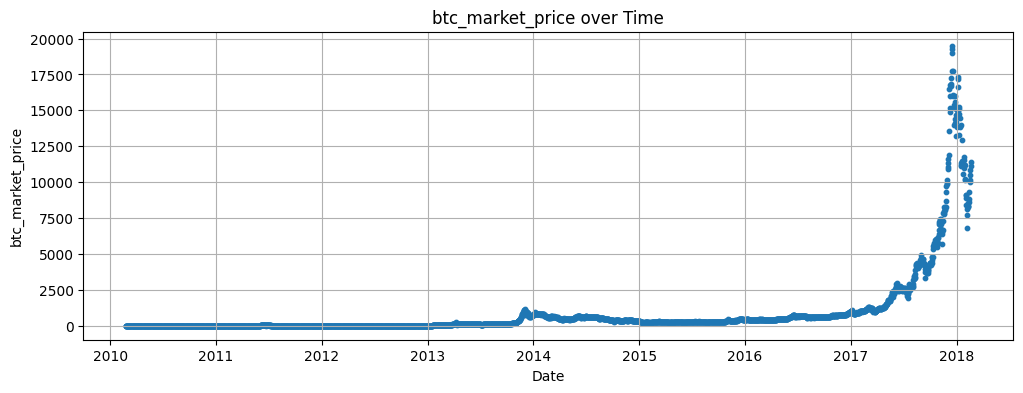

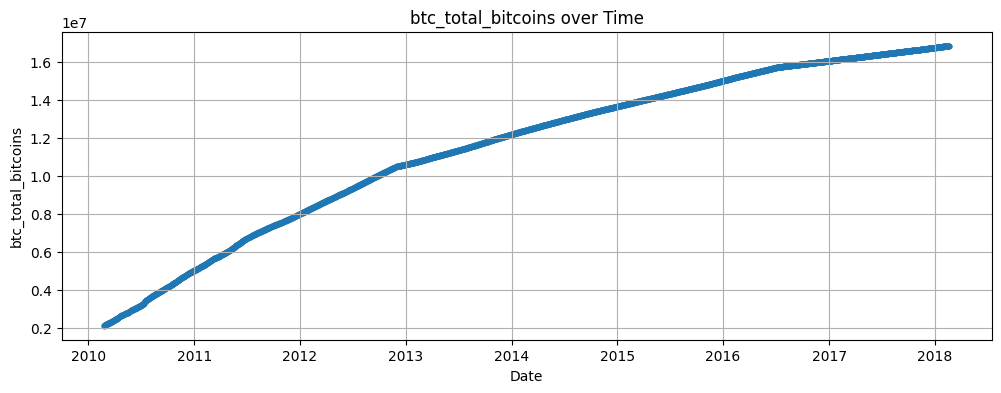

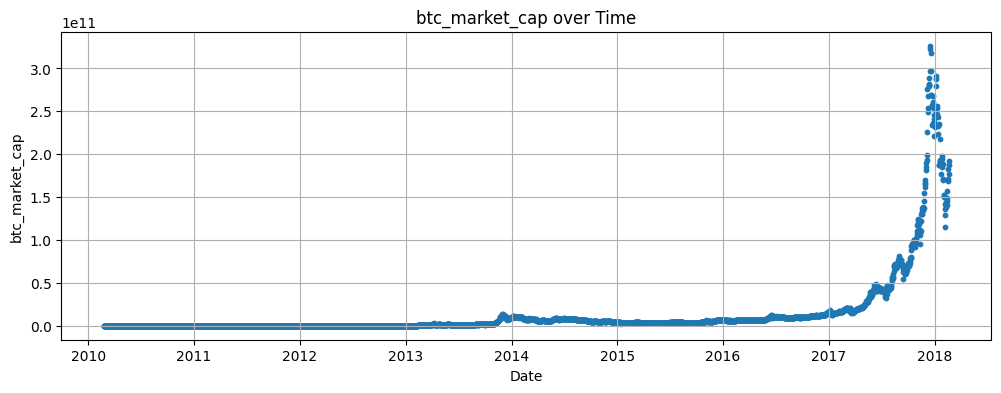

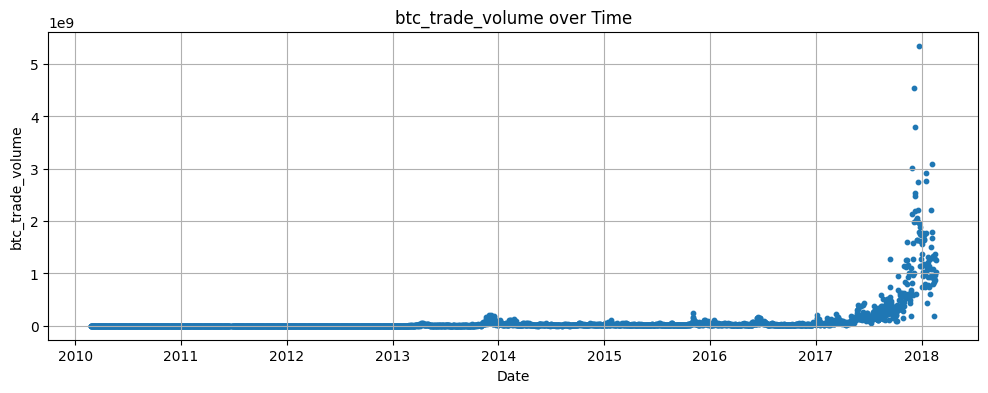

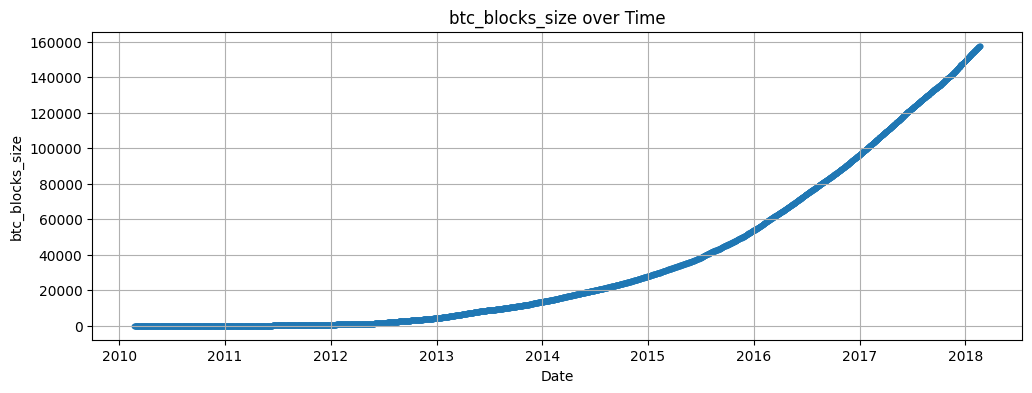

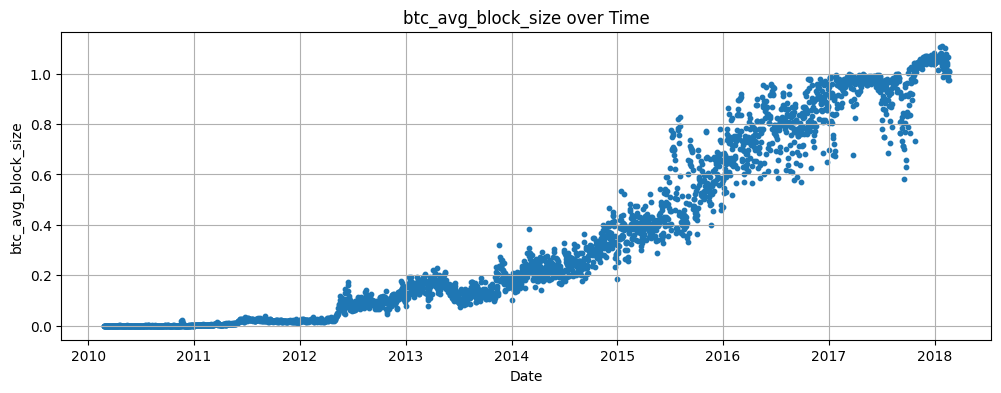

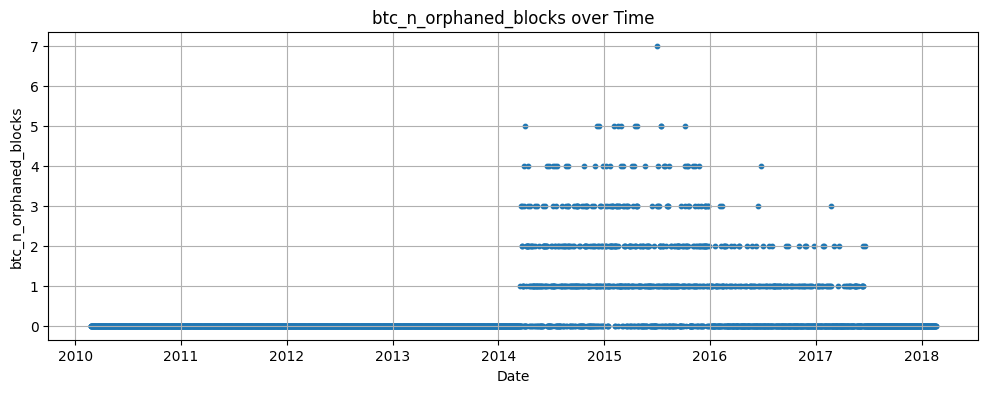

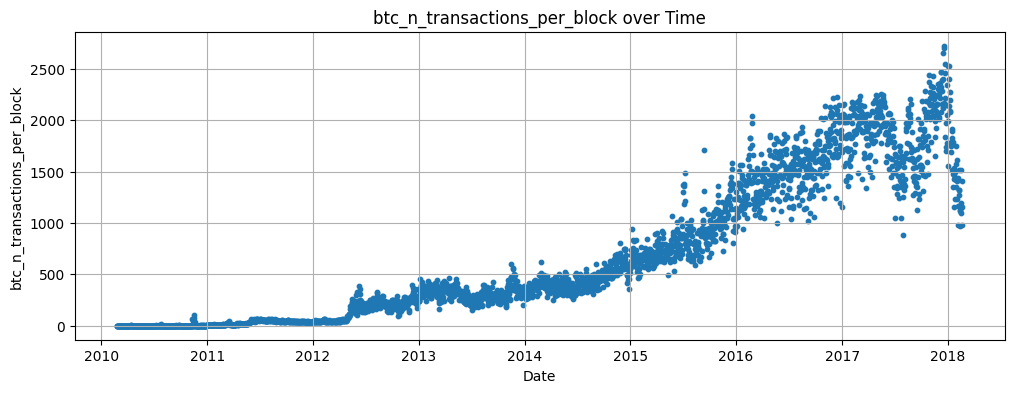

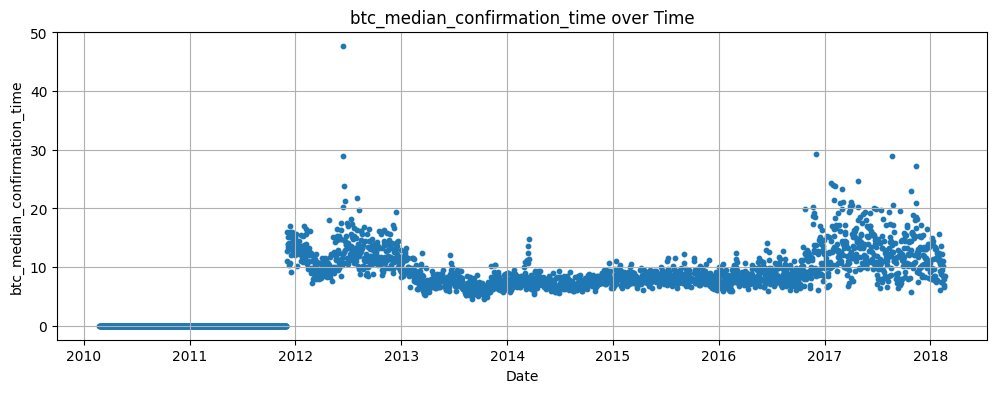

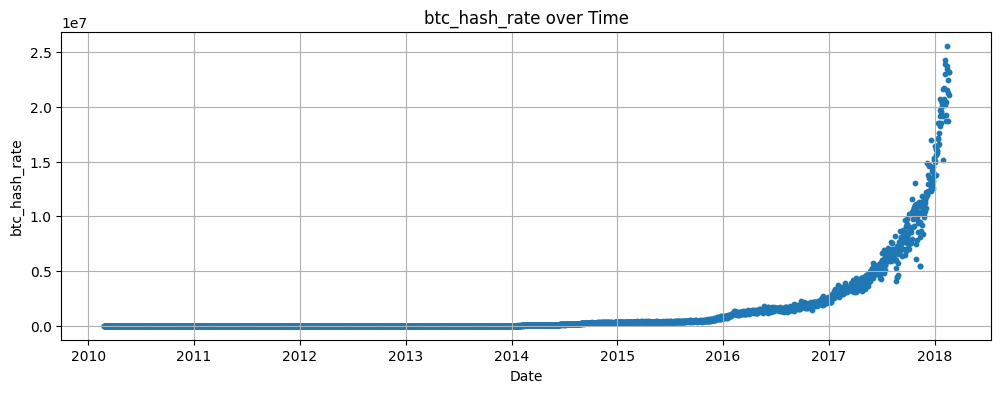

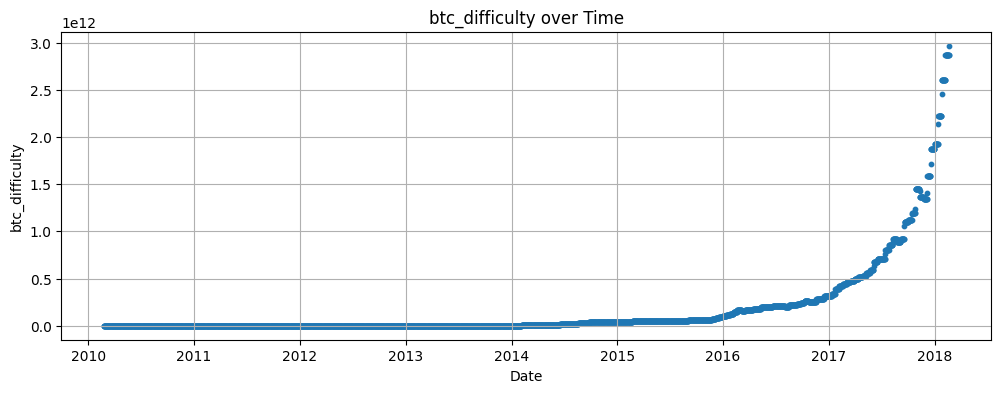

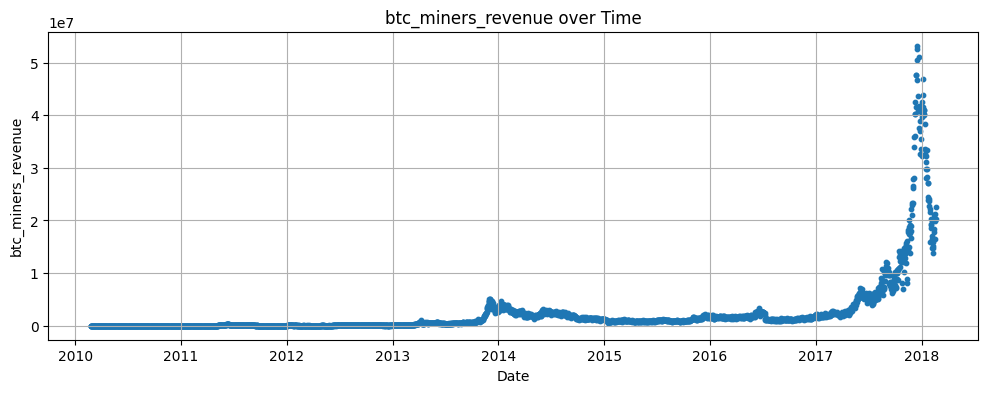

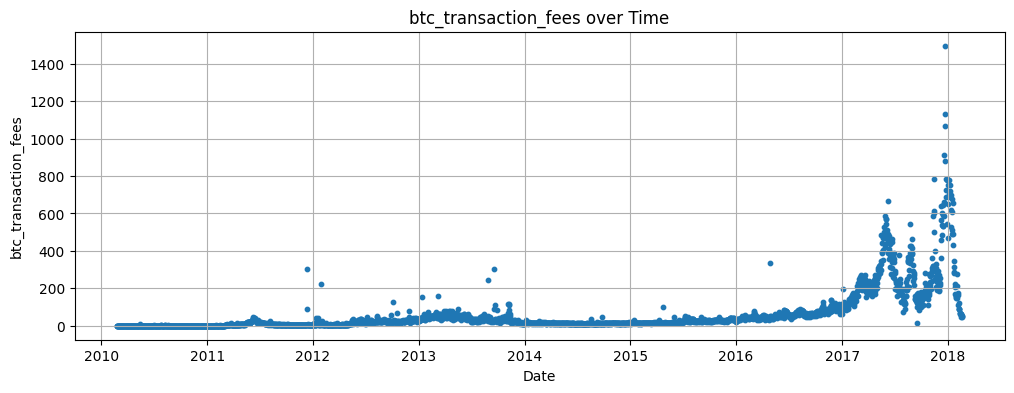

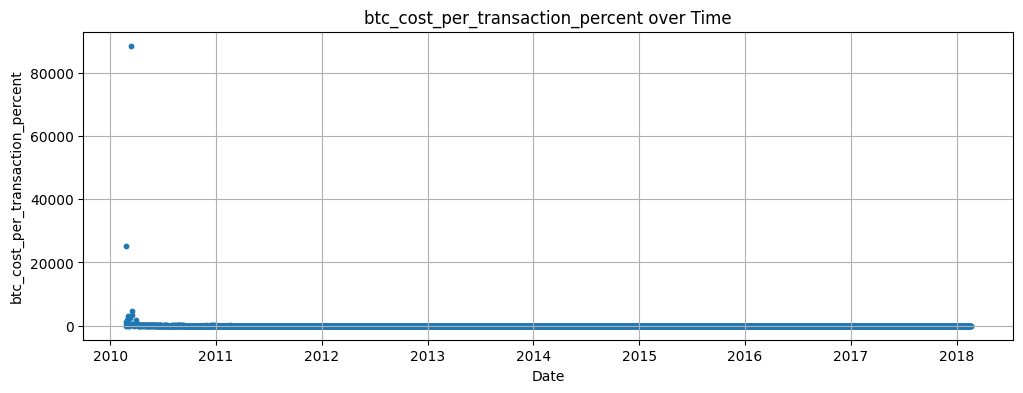

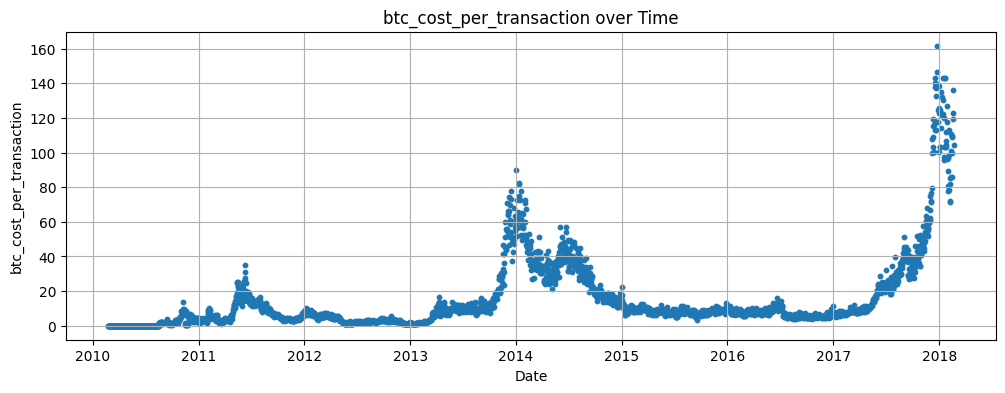

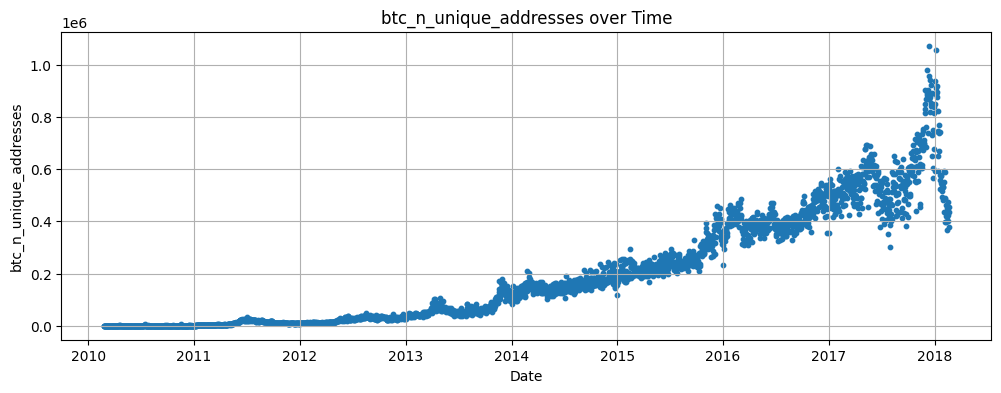

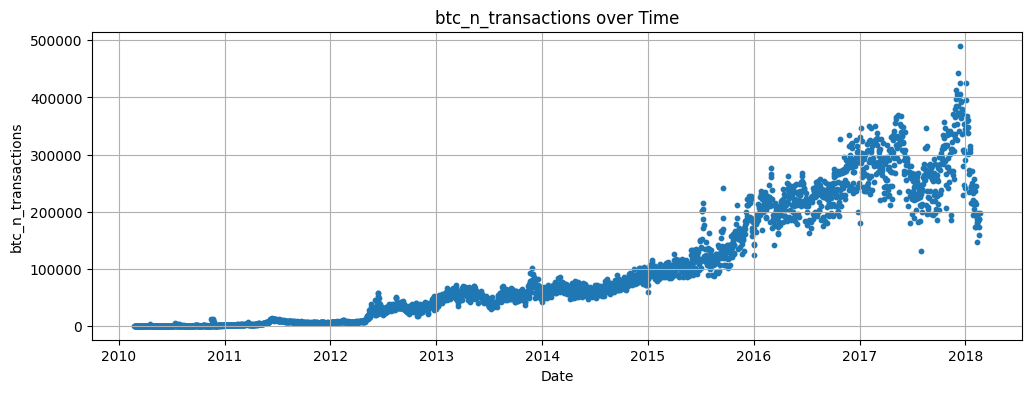

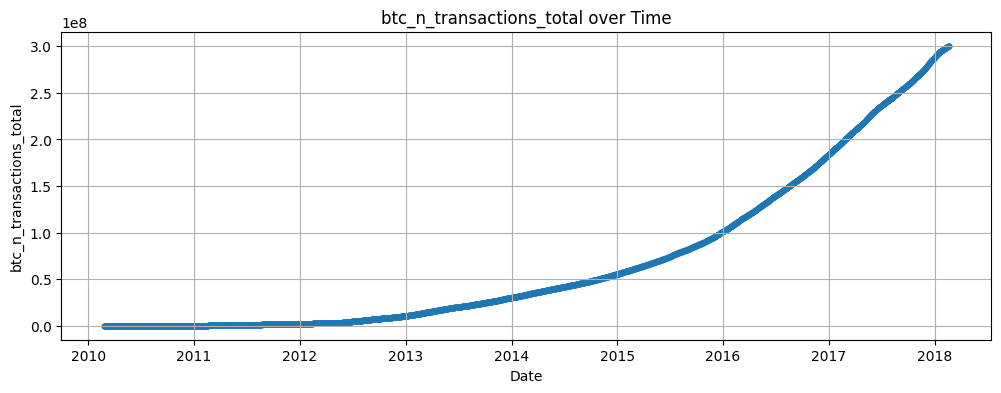

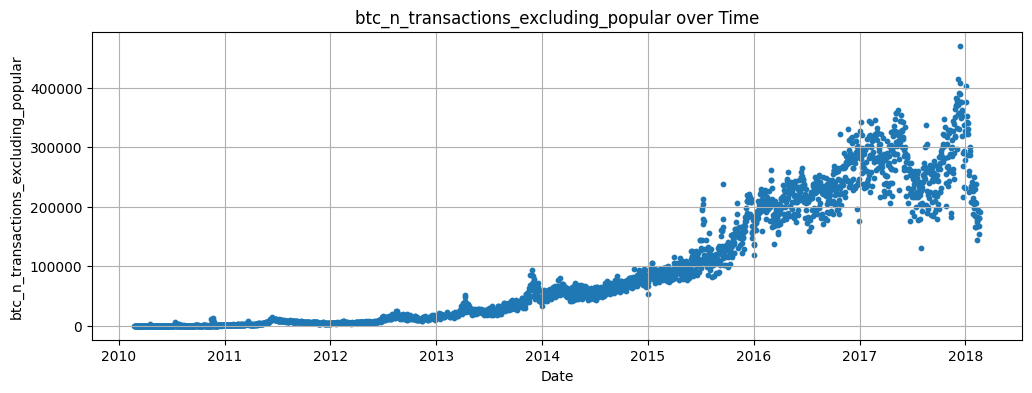

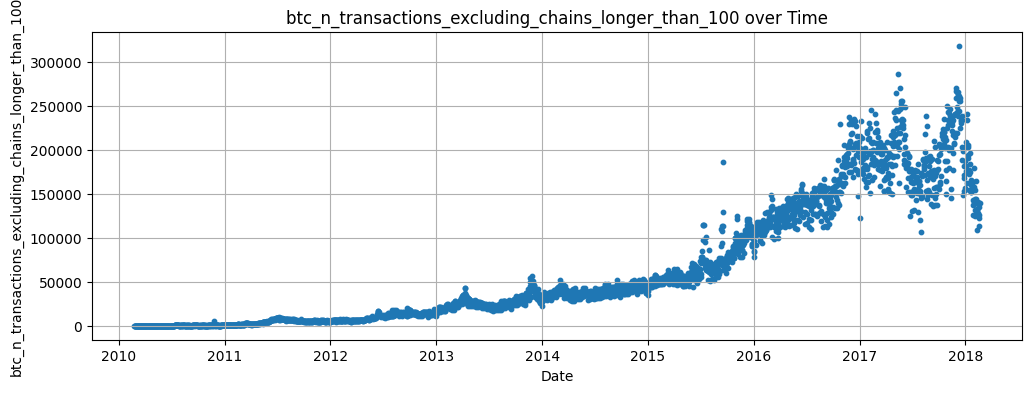

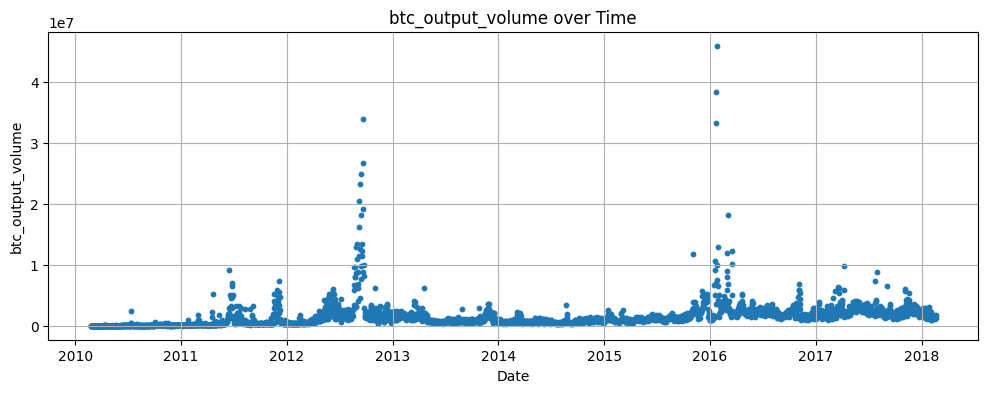

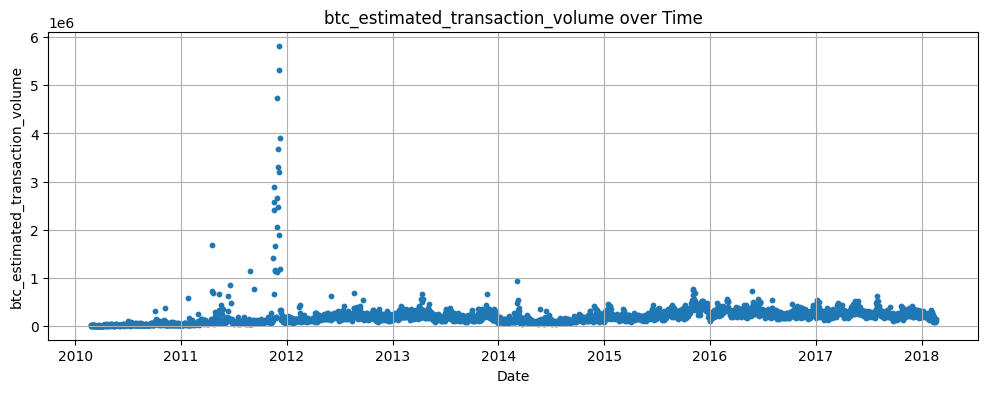

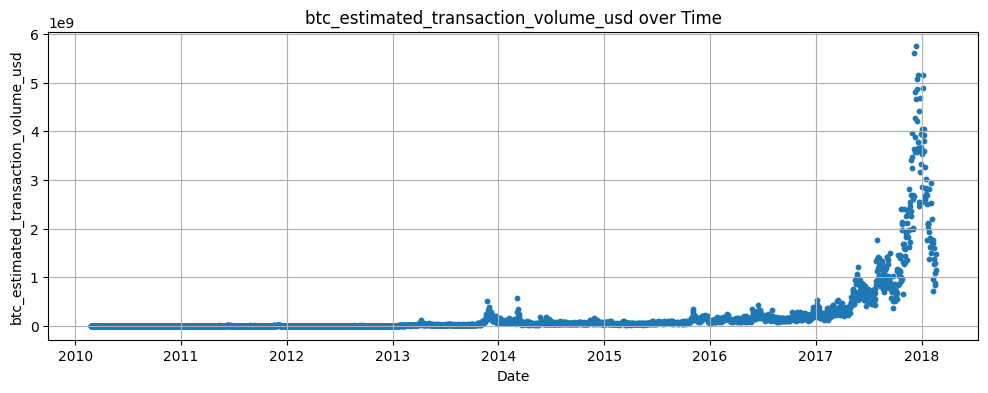

In [18]:
# Plot every variable by date
bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Date'])

num_cols = bitcoin_df.select_dtypes(include="number")

for col in num_cols.columns:
    plt.figure(figsize=(12,4))
    plt.scatter(bitcoin_df['Date'], bitcoin_df[col], s=10)
    plt.title(f"{col} over Time")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

It looks like there may be some outliers based on the plots. To better identify outliers, I'll look at boxplots in the data prep step after cleaning the null/zero data points. 

The instructions state there may be scaling issues. To check for this I'm going to create historgrams for each variable. 


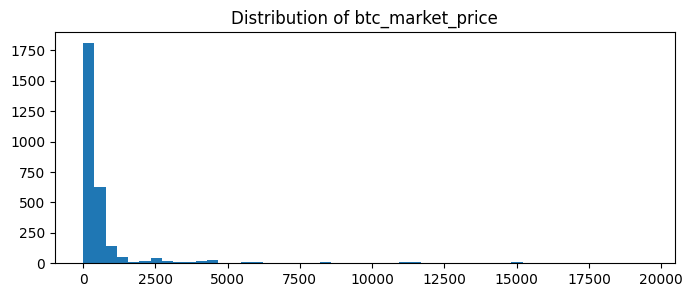

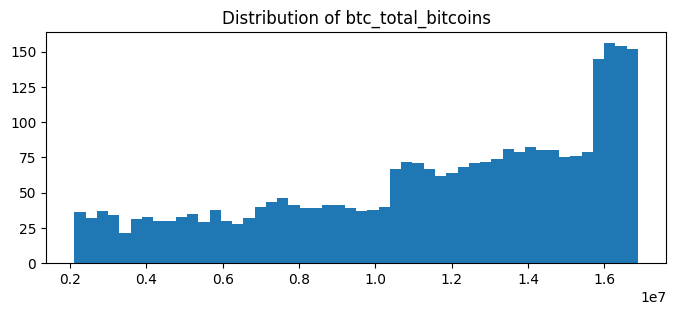

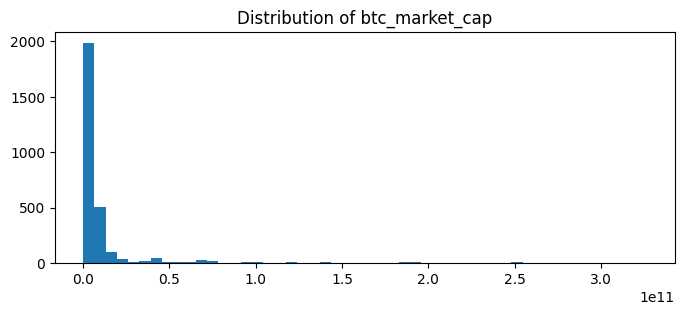

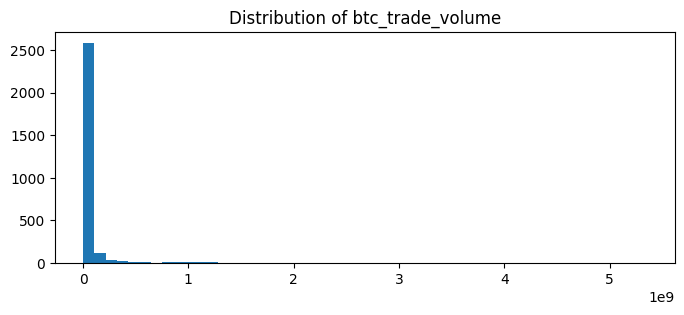

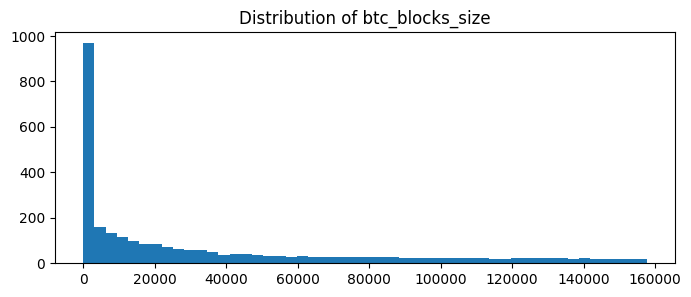

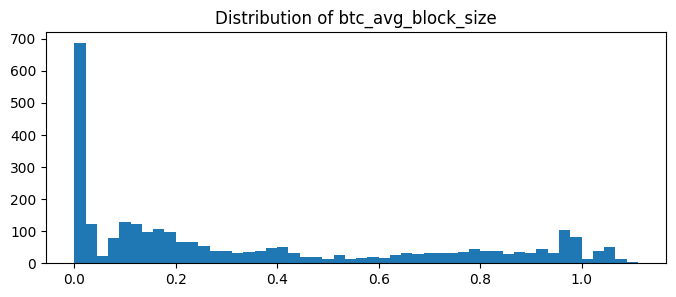

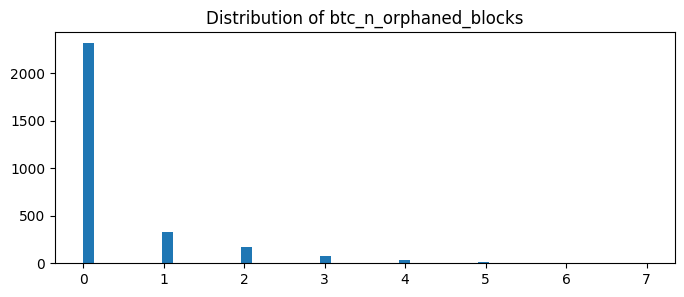

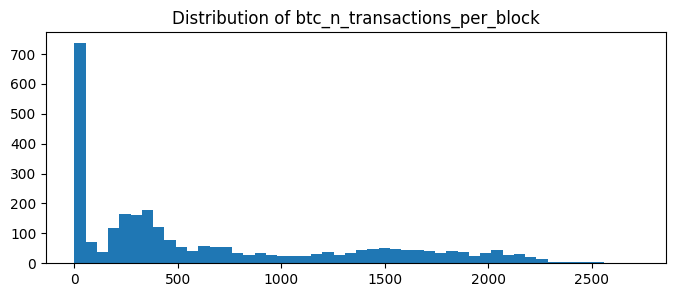

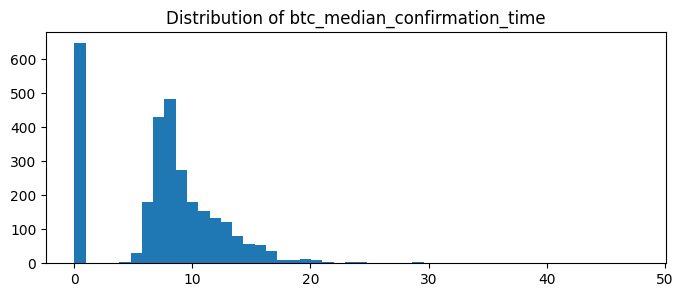

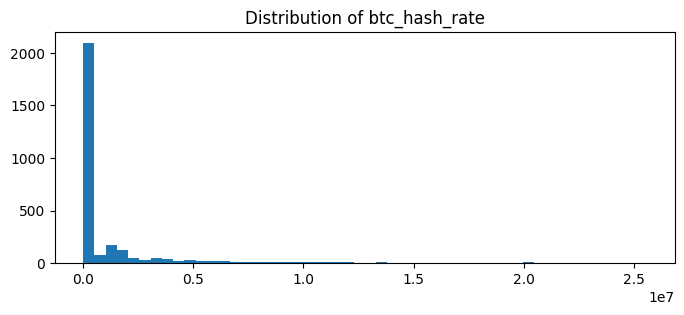

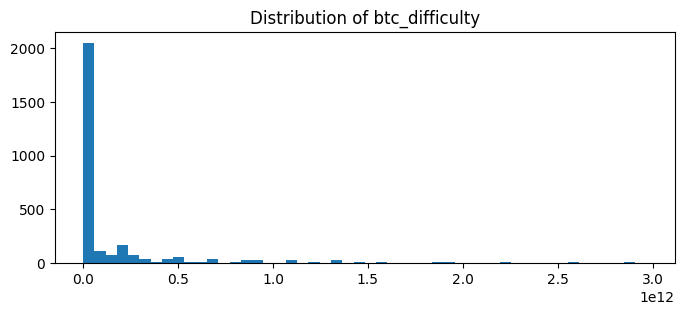

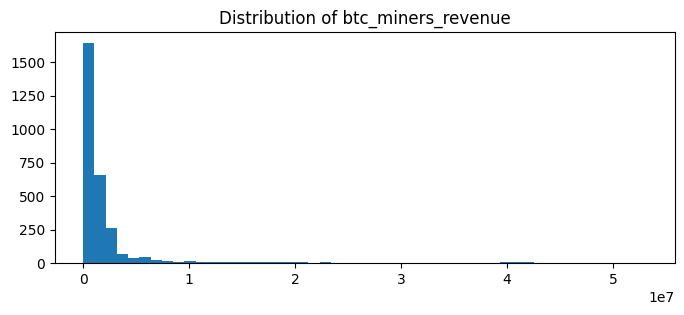

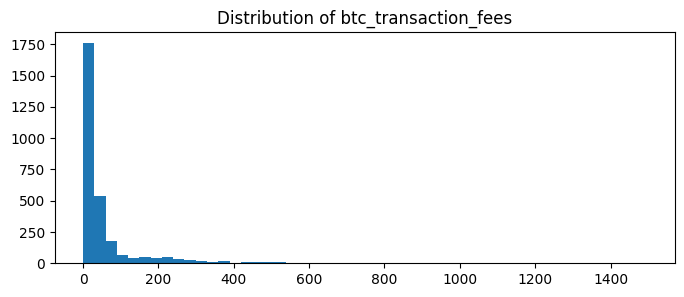

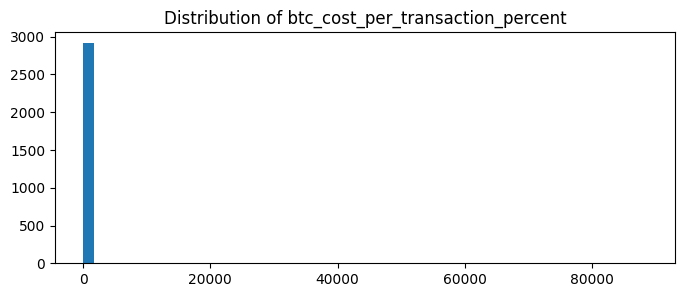

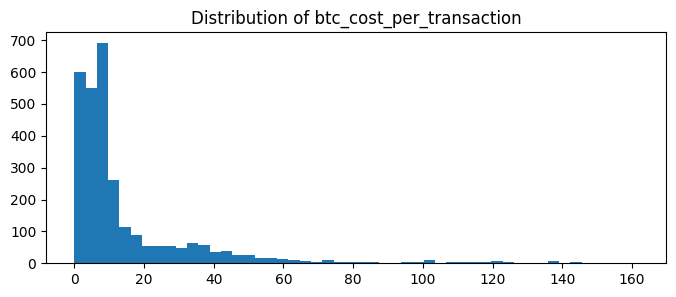

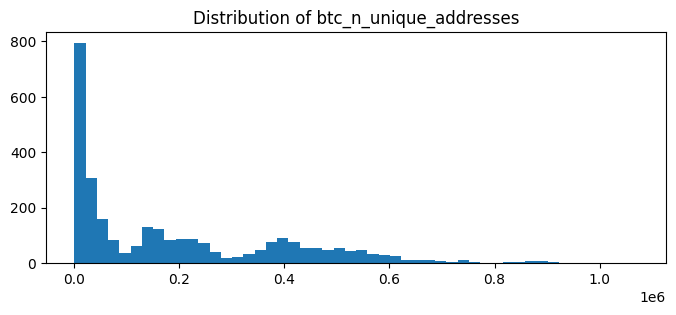

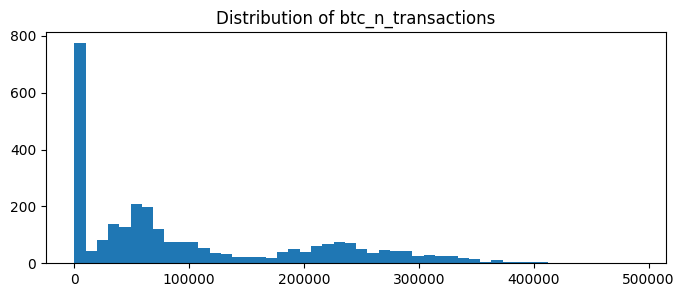

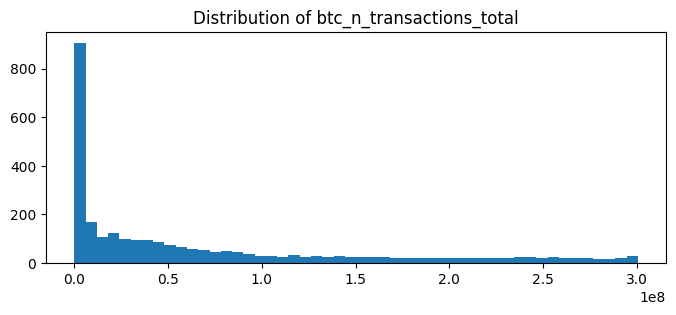

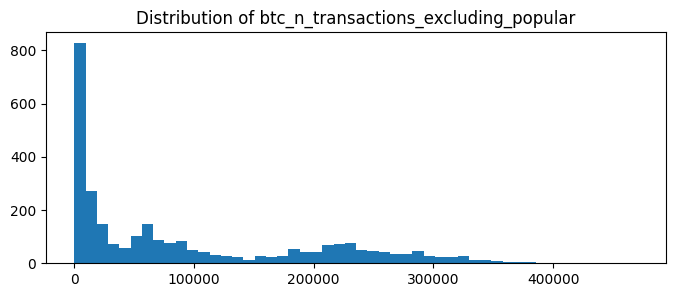

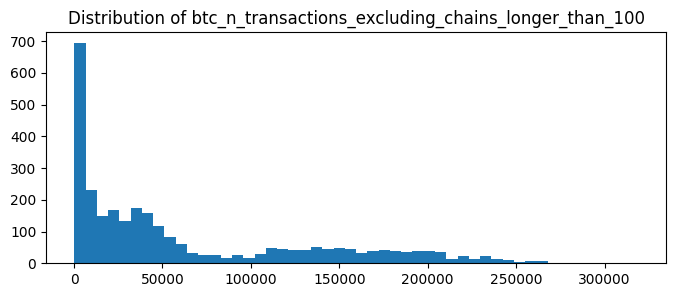

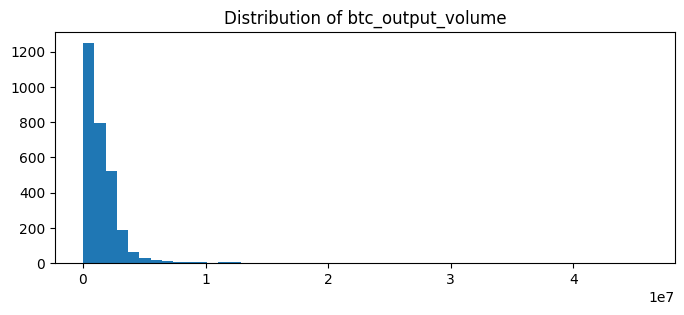

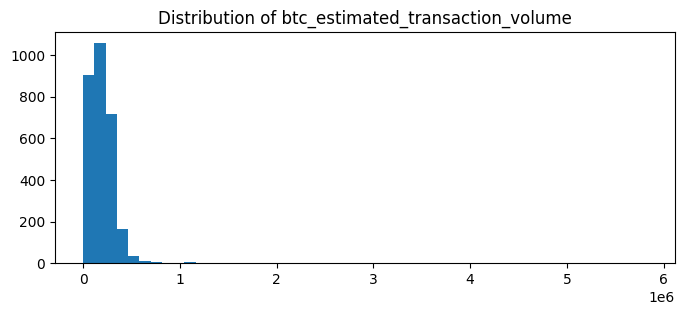

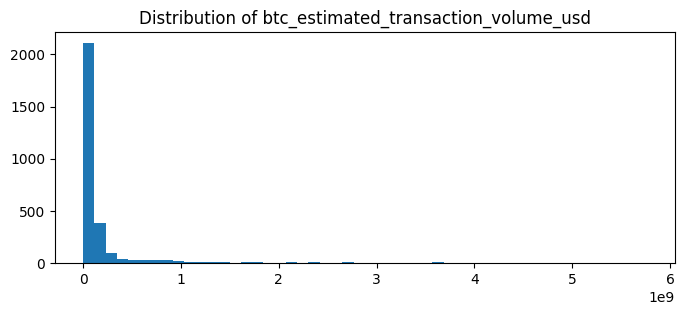

In [23]:
for col in num_cols.columns:
    plt.figure(figsize=(8,3))
    plt.hist(bitcoin_df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()